In [1]:
import sys
import pandas as pd
import tensorflow as tf
import platform
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.models import Model, load_model 
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
import psutil
import re

In [2]:



def beep():
    for i in range(5):
        os.system("afplay /System/Library/Sounds/Glass.aiff")


def load_model(model, model_name):

    if os.path.exists(f"./{model_name}.h5"):
        print(f"Loading existing model from .h5 format: {model_name}.h5")
        model = tf.keras.models.load_model(f"./{model_name}.h5")
    elif os.path.exists(f"./{model_name}.keras"):
        print(f"Loading existing model from .keras format: {model_name}.keras")
        model = tf.keras.models.load_model(f"./{model_name}.keras")
    else:
        print(f"No existing model found. Starting with a new model.")

    for layer in model.layers:
        if "mobilenetv2" in layer.name.lower():  # Ensure you're targeting the correct layers
            layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def save_model(model, model_name, epoch, e_start):
    
    num = 1 + e_start + epoch
    try:
        model.save(f"./{model_name}.h5")
        model.save(f"./backup_threshold_models/{model_name}_{num}epoch.h5")
    except:
        print("failed to save the model in h5 format")

    return model


def preprocess_chunk(chunk):
    # Select feature columns (start with 'pixel_')
    X = chunk.filter(regex=r'^pixel_').values
    X = X.reshape((-1, 224, 224, 3))
    # Select target columns (exclude those with 'image' in the name)
    Y = chunk.loc[:, ~((chunk.columns.str.contains('image')) | (chunk.columns.str.contains('pixel_')))].values
    return X, Y



def train_model(model, model_name, training_df_path1, training_df_path2, val_X, val_Y, e_start, epochs, chunksize, batch_size):
    model = load_model(model, model_name)
    val_acc_list = []
    val_loss_list = []
    val_epoch_list = []

    df2 = pd.read_csv(training_df_path2)  # Preload secondary dataset
    chunk_iter2 = iter([df2.iloc[i:i+chunksize] for i in range(0, len(df2), chunksize)])

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        sample_counter = 0

        chunk_iter1 = iter(pd.read_csv(training_df_path1, chunksize=chunksize))

        while True:
            try:
                chunk1 = next(chunk_iter1)
                X1, Y1 = preprocess_chunk(chunk1)

                try:
                    chunk2 = next(chunk_iter2)
                except StopIteration:
                    chunk_iter2 = iter([df2.iloc[i:i+chunksize] for i in range(0, len(df2), chunksize)])
                    chunk2 = next(chunk_iter2)

                X2, Y2 = preprocess_chunk(chunk2)

                if len(X2) < len(X1):
                    chunk_iter2 = iter([df2.iloc[i:i+chunksize] for i in range(0, len(df2), chunksize)])
                    chunk2 = next(chunk_iter2)
                    X2, Y2 = preprocess_chunk(chunk2)

                X2, Y2 = X2[:len(X1)], Y2[:len(Y1)]

                # Ensure no NaN values
                X1, Y1, X2, Y2 = map(np.nan_to_num, [X1, Y1, X2, Y2])

                X = np.concatenate([X1, X2], axis=0)
                Y = np.concatenate([Y1, Y2], axis=0)

                indices = np.random.permutation(len(X))
                X, Y = X[indices], Y[indices]

                dataset = tf.data.Dataset.from_tensor_slices((X.astype('float32'), Y.astype('float32')))
                dataset = dataset.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

                for batch_X, batch_Y in dataset:
                    loss, acc = model.train_on_batch(batch_X, batch_Y)
                    sample_counter += batch_X.shape[0]

                    if sample_counter % 500 == 0:
                        print(f"  Memory usage: {psutil.virtual_memory().percent}%")
                        print(f"Processed {sample_counter} samples - "
                              f"Batch Loss: {loss:.4f}, Batch Accuracy: {acc:.4f}")

                tf.keras.backend.clear_session()

            except StopIteration:
                break

        save_model(model, model_name, epoch, e_start)

        # print(f"Completed Epoch {epoch + 1}/{epochs}")
        # print(f"  Validating after Epoch {epoch + 1}/{epochs}...")
        # val_loss, val_acc = model.evaluate(val_X, val_Y, batch_size=batch_size)
        # val_acc_list.append(val_acc)
        # val_loss_list.append(val_loss)
        # val_epoch_list.append(e_start + 1 + epoch)
        # print(f"  Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")
        # print("----------------------------------")

                

        print(f"  Validating after Epoch {epoch + 1}/{epochs}...")

        # Get model predictions
        val_preds = model.predict(val_X, batch_size=batch_size)
        val_preds_classes = np.argmax(val_preds, axis=1)  # Convert softmax outputs to class indices
        true_classes = np.argmax(val_Y, axis=1)  # Convert one-hot labels to class indices

        # Define reject class index (assuming it's the last class)
        reject_class = val_Y.shape[1] - 1  

        # Compute rejection rate
        reject_mask = (val_preds_classes == reject_class)
        rejection_rate = np.mean(reject_mask)
        # Compute accuracy excluding rejected samples
        non_reject_mask = ~reject_mask
        if np.any(non_reject_mask):  # Avoid division by zero
            val_acc = np.mean(val_preds_classes[non_reject_mask] == true_classes[non_reject_mask])
        else:
            val_acc = 0  # If all samples are rejected, accuracy is undefined

        # Store metrics
        val_acc_list.append(val_acc)
        val_loss, _ = model.evaluate(val_X, val_Y, batch_size=batch_size)
        val_loss_list.append(val_loss)
        val_epoch_list.append(e_start + 1 + epoch)

        # Print results
        print(f"  Validation Loss: {val_loss:.4f}")
        print(f"  Non-Rejected Accuracy: {val_acc:.4f}")
        print(f"  Rejection Rate: {rejection_rate:.4%}")
        print("----------------------------------")



        if val_acc < 0.2 and epoch > 5:
            print(f"stopped at {epoch}, the model seems to crash already at {val_acc}")
            beep()
            return

    beep()
    return model, val_acc_list, val_loss_list, val_epoch_list

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to prevent TensorFlow from reserving all GPU memory upfront
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"TensorFlow is configured to use {len(gpus)} GPU(s).")
    except RuntimeError as e:
        print(f"Error while setting GPU configuration: {e}")
else:
    print("No GPU found. Running on CPU.")

# Now it is safe to perform any TensorFlow operations
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

#  add rejection output option (no real example will have 1 for it)

validation_df_path = "./ordered_validation_df.csv"
validation_df = pd.read_csv(validation_df_path)
validation_df["RJ"] = 0
val_X, val_Y = preprocess_chunk(validation_df)

lr = 0.01


No GPU found. Running on CPU.
Num GPUs Available:  0


-----
model_rj_with_threshold_0.3, 0.3
0
No existing model found. Starting with a new model.
Epoch 1/5
  Memory usage: 85.8%
Processed 1000 samples - Batch Loss: 1.5231, Batch Accuracy: 0.6660

  Memory usage: 84.7%
Processed 2000 samples - Batch Loss: 1.2024, Batch Accuracy: 0.7160
  Memory usage: 86.8%
Processed 3000 samples - Batch Loss: 1.4913, Batch Accuracy: 0.6673
  Memory usage: 81.1%
Processed 4000 samples - Batch Loss: 1.3652, Batch Accuracy: 0.6915
  Memory usage: 81.7%
Processed 5000 samples - Batch Loss: 1.5597, Batch Accuracy: 0.6536
  Memory usage: 82.5%
Processed 6000 samples - Batch Loss: 1.5060, Batch Accuracy: 0.6655
  Memory usage: 82.9%
Processed 7000 samples - Batch Loss: 1.5247, Batch Accuracy: 0.6534
  Memory usage: 86.1%
Processed 8000 samples - Batch Loss: 1.4714, Batch Accuracy: 0.6615
  Memory usage: 86.3%
Processed 9000 samples - Batch Loss: 1.4931, Batch Accuracy: 0.6612
  Memory usage: 84.3%
Processed 10000 samples - Batch Loss: 1.4527, Batch Accuracy: 0.

  Validating after Epoch 1/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 893ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 496ms/step - accuracy: 0.5306 - loss: 2.4328
  Validation Loss: 2.4607
  Non-Rejected Accuracy: 0.5579
  Rejection Rate: 1.5544%
----------------------------------
Epoch 2/5
  Memory usage: 87.1%
Processed 1000 samples - Batch Loss: 2.8424, Batch Accuracy: 0.5943
  Memory usage: 82.5%
Processed 2000 samples - Batch Loss: 2.8313, Batch Accuracy: 0.5923
  Memory usage: 86.5%
Processed 3000 samples - Batch Loss: 2.5758, Batch Accuracy: 0.6373
  Memory usage: 87.8%
Processed 4000 samples - Batch Loss: 2.6657, Batch Accuracy: 0.6432
  Memory usage: 81.8%
Processed 5000 samples - Batch Loss: 2.5167, Batch Accuracy: 0.6686
  Memory usage: 83.8%
Processed 6000 samples - Batch Loss: 3.0313, Batch Accuracy: 0.6494
  Memory usage: 85.2%
Processed 7000 samples - Batch Loss: 2.7758, Batch Accuracy: 0.6651
  Memory usage: 85.6%
Processed 8000 samples - Batch Loss: 2.7388, Batch Accuracy: 0.6514
  Memor

  Validating after Epoch 2/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 682ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - accuracy: 0.5057 - loss: 3.2752
  Validation Loss: 3.3774
  Non-Rejected Accuracy: 0.7951
  Rejection Rate: 36.7876%
----------------------------------
Epoch 3/5
  Memory usage: 86.4%
Processed 1000 samples - Batch Loss: 2.0976, Batch Accuracy: 0.6572
  Memory usage: 82.7%
Processed 2000 samples - Batch Loss: 1.6386, Batch Accuracy: 0.7022
  Memory usage: 83.3%
Processed 3000 samples - Batch Loss: 1.7199, Batch Accuracy: 0.6693
  Memory usage: 83.0%
Processed 4000 samples - Batch Loss: 1.5285, Batch Accuracy: 0.6988
  Memory usage: 85.2%
Processed 5000 samples - Batch Loss: 1.6117, Batch Accuracy: 0.6821
  Memory usage: 83.2%
Processed 6000 samples - Batch Loss: 1.5357, Batch Accuracy: 0.6913
  Memory usage: 85.3%
Processed 7000 samples - Batch Loss: 1.5461, Batch Accuracy: 0.6954
  Memory usage: 84.1%
Processed 8000 samples - Batch Loss: 1.4720, Batch Accuracy: 0.7061
  Memo

  Validating after Epoch 3/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 705ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 496ms/step - accuracy: 0.5644 - loss: 3.4236
  Validation Loss: 3.2623
  Non-Rejected Accuracy: 0.7273
  Rejection Rate: 20.2073%
----------------------------------
Epoch 4/5
  Memory usage: 86.9%
Processed 1000 samples - Batch Loss: 3.7659, Batch Accuracy: 0.6169
  Memory usage: 83.7%
Processed 2000 samples - Batch Loss: 3.4924, Batch Accuracy: 0.6334
  Memory usage: 84.7%
Processed 3000 samples - Batch Loss: 3.1352, Batch Accuracy: 0.6827
  Memory usage: 84.8%
Processed 4000 samples - Batch Loss: 3.2803, Batch Accuracy: 0.6706
  Memory usage: 86.6%
Processed 5000 samples - Batch Loss: 2.9793, Batch Accuracy: 0.6850
  Memory usage: 81.8%
Processed 6000 samples - Batch Loss: 2.9329, Batch Accuracy: 0.6711
  Memory usage: 82.1%
Processed 7000 samples - Batch Loss: 2.7794, Batch Accuracy: 0.6722
  Memory usage: 84.5%
Processed 8000 samples - Batch Loss: 2.7065, Batch Accuracy: 0.6639
  Memo

  Validating after Epoch 4/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 700ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - accuracy: 0.5618 - loss: 2.3093
  Validation Loss: 2.3514
  Non-Rejected Accuracy: 0.8134
  Rejection Rate: 30.5699%
----------------------------------
Epoch 5/5
  Memory usage: 85.8%
Processed 1000 samples - Batch Loss: 1.9030, Batch Accuracy: 0.6060
  Memory usage: 84.3%
Processed 2000 samples - Batch Loss: 1.5541, Batch Accuracy: 0.6689
  Memory usage: 82.8%
Processed 3000 samples - Batch Loss: 1.6893, Batch Accuracy: 0.6633
  Memory usage: 83.1%
Processed 4000 samples - Batch Loss: 1.5539, Batch Accuracy: 0.6892
  Memory usage: 83.7%
Processed 5000 samples - Batch Loss: 1.7897, Batch Accuracy: 0.6817
  Memory usage: 84.5%
Processed 6000 samples - Batch Loss: 1.6830, Batch Accuracy: 0.6982
  Memory usage: 85.2%
Processed 7000 samples - Batch Loss: 1.6357, Batch Accuracy: 0.7050
  Memory usage: 86.6%
Processed 8000 samples - Batch Loss: 1.5603, Batch Accuracy: 0.7134
  Memo

  Validating after Epoch 5/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 704ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 499ms/step - accuracy: 0.5504 - loss: 3.1929
  Validation Loss: 3.0497
  Non-Rejected Accuracy: 0.8699
  Rejection Rate: 36.2694%
----------------------------------
[np.float64(0.5578947368421052), np.float64(0.7950819672131147), np.float64(0.7272727272727273), np.float64(0.8134328358208955), np.float64(0.8699186991869918)]


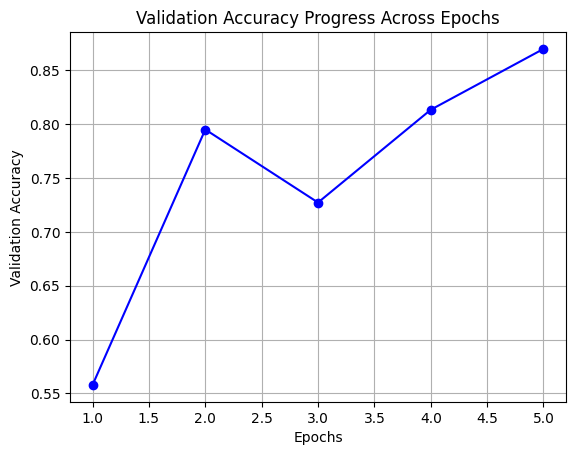

In [4]:
for cur_threshold in [0.3]:

    print('-----')
    arr = os.listdir()
    files = os.listdir("./training_diff_thresholds_final")

    chunksize = 500  # Number of rows to process at a time
    batch_size = 64
    # epochs = 24
    epochs = 5
    model_name = f"model_rj_with_threshold_{cur_threshold}"

    training_df_path1 = f"./training_diff_thresholds_final/training_data_threshold_{cur_threshold}.csv"
    training_df_path2  = f"./training_diff_thresholds_final/training_augmented_data_threshold_{cur_threshold}.csv"


    print(f"{model_name}, {cur_threshold}")


    epoch_pattern = re.compile(f"{model_name}"+r'_(\d+)epoch')

    latest_epoch = -1
    latest_file = None
    for file in arr:
        match = epoch_pattern.search(file)
        if match:
            epoch = int(match.group(1))
            if epoch > latest_epoch:
                latest_epoch = epoch
                latest_file = file

    if latest_epoch == -1:
        e_start = 0
    else:
        e_start = latest_epoch

    print(e_start)


    """mobilenet with  basic head version"""
    # get MobileNetV2 as the base of the model and add the head for the classification
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Global pooling to reduce dimensions
    predictions = Dense(8, activation='softmax')(x)  # 7 classes with softmax, now with RJ set to 8
    model = Model(inputs=base_model.input, outputs=predictions)

    # freeze MobileNetV2 weights
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=lr),
                loss='categorical_crossentropy',
                metrics=['accuracy'])



    # Define the model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=lr),
                loss='categorical_crossentropy',
                metrics=['accuracy'])



    model, val_acc_list, val_loss_list, val_epoch_list = train_model(model, model_name, training_df_path1, training_df_path2, val_X, val_Y, e_start, epochs, chunksize, batch_size)


    print(val_acc_list)
    plt.plot(val_epoch_list, val_acc_list, marker='o', linestyle='-', color='b')

    # Adding labels and title
    plt.xlabel('Epochs')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy Progress Across Epochs')

    # Display the plot
    plt.grid(True)
    plt.show()

In [ ]:


print(f"  Validating after Epoch {epoch + 1}/{epochs}...")

# Get model predictions
val_preds = model.predict(val_X, batch_size=batch_size)
val_preds_classes = np.argmax(val_preds, axis=1)  # Convert softmax outputs to class indices
true_classes = np.argmax(val_Y, axis=1)  # Convert one-hot labels to class indices

# Define reject class index (assuming it's the last class)
reject_class = val_Y.shape[1] - 1  

# Compute rejection rate
reject_mask = (val_preds_classes == reject_class)
rejection_rate = np.mean(reject_mask)

# Compute accuracy excluding rejected samples
non_reject_mask = ~reject_mask
if np.any(non_reject_mask):  # Avoid division by zero
valid_acc = np.mean(val_preds_classes[non_reject_mask] == true_classes[non_reject_mask])
else:
valid_acc = 0  # If all samples are rejected, accuracy is undefined

# Store metrics
val_acc_list.append(valid_acc)
val_loss, _ = model.evaluate(val_X, val_Y, batch_size=batch_size)
val_loss_list.append(val_loss)
val_epoch_list.append(e_start + 1 + epoch)

# Print results
print(f"  Validation Loss: {val_loss:.4f}")
print(f"  Non-Rejected Accuracy: {valid_acc:.4f}")
print(f"  Rejection Rate: {rejection_rate:.4%}")
print("----------------------------------")